In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV,  RandomizedSearchCV
from scipy.stats import randint


In [21]:
wine = pd.read_csv("wine.csv")

# 2. 입력(X) / 정답(y) 나누기
# 컬럼 이름이 정확히 alcohol, sugar, pH, class 라고 가정
X = wine[['alcohol', 'sugar', 'pH']]
y = wine['class']

# 3. 훈련용 / 테스트용 데이터 분리
train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)

model = RandomForestClassifier(n_jobs=-1, random_state=42 ,max_depth=12)
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #10 폴드로 나누는 분할기로 만듬

# 5. 교차검증
scores = cross_validate(model, train_input, train_target, return_train_score=True, n_jobs=1)

print(np.mean(scores['train_score']))

0.9698990895655862


테스트 정확도: 0.8830769230769231

분류 리포트:
              precision    recall  f1-score   support

         0.0       0.78      0.74      0.76       160
         1.0       0.92      0.93      0.92       490

    accuracy                           0.88       650
   macro avg       0.85      0.83      0.84       650
weighted avg       0.88      0.88      0.88       650


특성 중요도:
alcohol : 0.21049525848526582
sugar : 0.541442146487094
pH : 0.24806259502764016


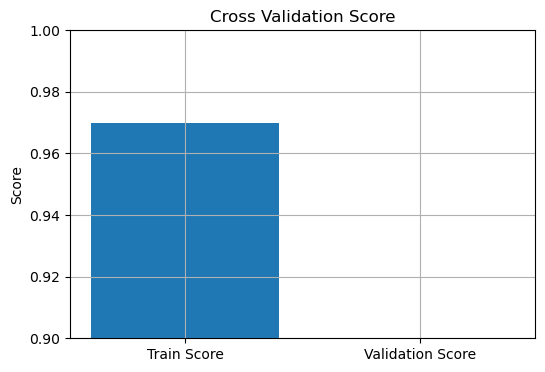

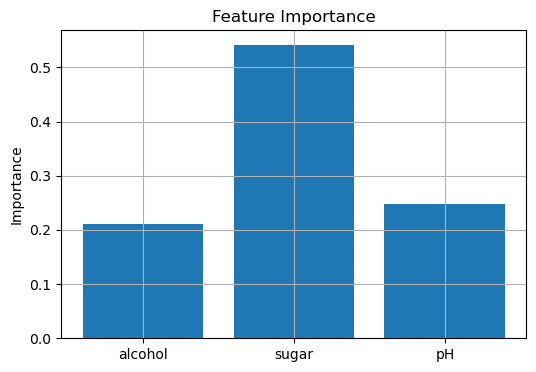

In [22]:
model.fit(train_input, train_target)

# 7. 예측
pred = model.predict(test_input)

# 8. 정확도 확인
print("테스트 정확도:", accuracy_score(test_target, pred))
print("\n분류 리포트:")
print(classification_report(test_target, pred))

# 9. 특성 중요도 출력
print("\n특성 중요도:")
for name, score in zip(X.columns, model.feature_importances_):
    print(name, ":", score)

# 10. 그래프 1 - 교차검증 train/test 점수
train_scores_mean = np.mean(scores['train_score'])
test_scores_mean = np.mean(scores['test_score'])

plt.figure(figsize=(6, 4))
plt.bar(['Train Score', 'Validation Score'], [train_scores_mean, test_scores_mean])
plt.ylim(0.9, 1.0)
plt.ylabel('Score')
plt.title('Cross Validation Score')
plt.grid(True)
plt.show()

# 11. 그래프 2 - 특성 중요도
plt.figure(figsize=(6, 4))
plt.bar(X.columns, model.feature_importances_)
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.grid(True)
plt.show()

In [23]:
print("최종 훈련 점수:", model.score(train_input, train_target))
print("최종 테스트 점수:", model.score(test_input, test_target))

최종 훈련 점수: 0.9651103129810159
최종 테스트 점수: 0.8830769230769231
